In [3]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
from datasets import load_dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

In [4]:
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])

In [5]:
def clean(job_skills):
    if pd.notna(job_skills):
        return ast.literal_eval(job_skills)

In [6]:
df['job_skills']=df['job_skills'].apply(clean)

In [9]:
type(df['job_skills'][2])

list

In [12]:
df_us=df[(df['job_country']=='United States')]

In [14]:
df_us_explode=df_us.explode('job_skills')

In [23]:
top3=df_us_explode['job_title_short'].value_counts().head(3).index.to_list()

In [24]:
top3

['Data Scientist', 'Data Analyst', 'Data Engineer']

In [30]:
df_new=df_us_explode.loc[:,('job_title_short','job_skills')]

In [33]:
df_new['job_title_short'].value_counts()

job_title_short
Data Scientist               322290
Data Analyst                 254289
Data Engineer                250493
Senior Data Engineer          76957
Senior Data Scientist         73388
Senior Data Analyst           53025
Business Analyst              26518
Software Engineer              9147
Machine Learning Engineer      5517
Cloud Engineer                 1941
Name: count, dtype: int64

In [34]:
df_new

,job_title_short,job_skills
0,Senior Data Engineer,None
3,Data Engineer,python
3,Data Engineer,c++
3,Data Engineer,java
3,Data Engineer,matlab
...,...,...
785692,Data Scientist,r
785703,Data Analyst,None
785705,Data Analyst,sql
785705,Data Analyst,python


In [35]:
df_skills_count = df_new.groupby(['job_skills', 'job_title_short']).size()

# Name the count column as count
df_skills_count = df_skills_count.reset_index(name='skill_count')

# Sort the values by skill_count in descending order
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
245,clojure,Software Engineer,1
1738,vb.net,Senior Data Scientist,1
530,fortran,Machine Learning Engineer,1
1116,planner,Cloud Engineer,1


In [36]:
import seaborn as sns

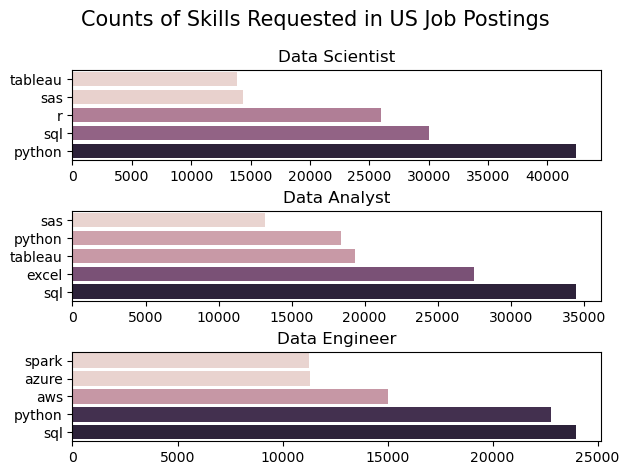

In [77]:
fig, ax=plt.subplots(3,1)
for i,top in enumerate(top3):
    new=df_skills_count[df_skills_count['job_title_short']==top].head(5)[::-1]
    sns.barplot(data=new,x='skill_count',y='job_skills',hue='skill_count',ax=ax[i])
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_title(top)
fig.suptitle('Counts of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5) # fix the overlap
plt.show()


In [63]:
new

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1523,sql,Data Scientist,30034
1243,r,Data Scientist,26022
1351,sas,Data Scientist,14340
1613,tableau,Data Scientist,13859
...,...,...,...
86,asp.net core,Data Scientist,1
1592,symfony,Data Scientist,1
857,mattermost,Data Scientist,1
487,fedora,Data Scientist,1
